# Debug the intervention feature

In [ ]:
!git clone https://github.com/mGarbowski/zzsn-projekt.git
!cd zzsn-projekt && git checkout intervention

In [1]:
import os
os.chdir('zzsn-projekt')
os.getcwd()

'/content/zzsn-projekt'

In [2]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: mikolaj-garbowski (mikolaj-garbowski-warsaw-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [10]:
from models.diffusion import WrappedDiffusion
import torch

wrapped_diffusion = WrappedDiffusion.from_pretrained(
    schmidhuber_artifact_id="mikolaj-garbowski-warsaw-university-of-technology/zzsn-projekt/model-x5d826nr-epoch_3:v0",
    device=device,
    torch_dtype=torch.float16,
    safety_checker=None
)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its result

In [5]:
from models.diffusion import GenerationParams
params = GenerationParams(
    prompts=["A picture of a british shorthair cat"],
    num_seeds=1,
    num_inference_steps=50,
    guidance_scale=7.5
)

In [6]:
result_no_intervention = wrapped_diffusion.generate(params)

  0%|          | 0/50 [00:00<?, ?it/s]

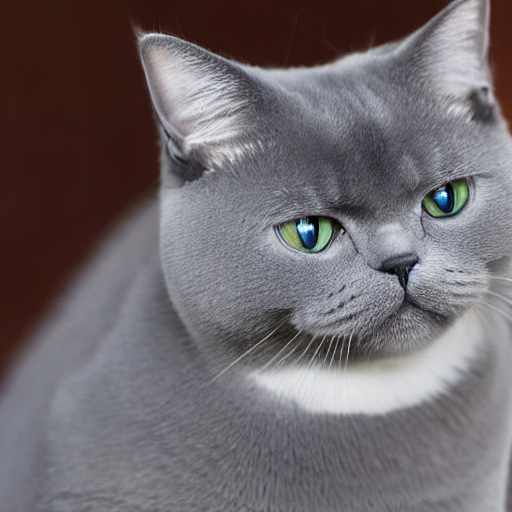

In [7]:
result_no_intervention[0].image

In [11]:
multipliers = {
    key: 0 for key in range(10, 50)
}
result_with_intervention = wrapped_diffusion.generate_with_intervention(params, multipliers)

  0%|          | 0/50 [00:00<?, ?it/s]

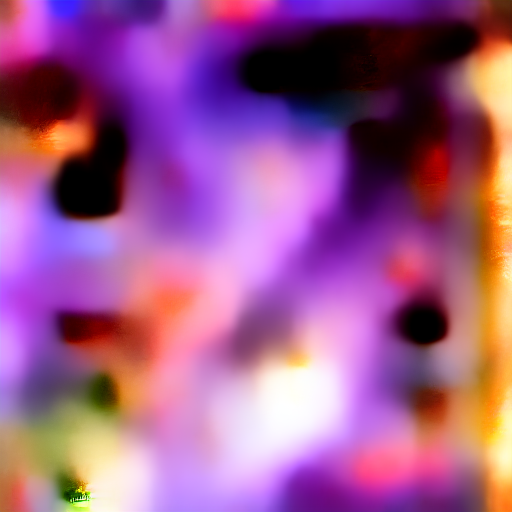

In [12]:
result_with_intervention[0].image